In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Circle
from scipy.stats import gmean, hmean

In [2]:
plt.rcParams['lines.markersize'] = 10
plt.style.use('tableau-colorblind10')
# from cycler import cycler
# plt.rcParams['axes.prop_cycle'] = cycler('color', plt.get_cmap('Dark2').colors)

### when LOWER values for both are preferred

In [3]:
def welfare(x, y, weight_x=1, weight_y=1):
    # print(x, (weight_x*x))
    # print((weight_x*x) + (weight_y*y))
    welfare = (weight_x*x) + (weight_y*y)
    idx_amax = np.argmax(welfare)
    print(f'welfare: {welfare[idx_amax]}, x: {x[idx_amax]}, y:{y[idx_amax]}')
    return (x[idx_amax], y[idx_amax])

[1.         0.83333333 0.71428571 0.625      0.55555556 0.5
 0.45454545 0.41666667 0.38461538 0.35714286 0.33333333 0.3125
 0.29411765 0.27777778 0.26315789 0.25       0.23809524 0.22727273
 0.2173913  0.20833333] 4.799999999999999
[1.         0.82644628 0.69444444 0.59171598 0.51020408 0.44444444
 0.390625   0.34602076 0.30864198 0.27700831 0.25       0.22675737
 0.20661157] 4.840000000000004
[1.         0.8638376  0.7513148  0.65751623 0.5787037  0.512
 0.45516614 0.40644211 0.36443149 0.32801673 0.2962963  0.26853748
 0.24414062 0.22261179 0.20354162] 4.913000000000006


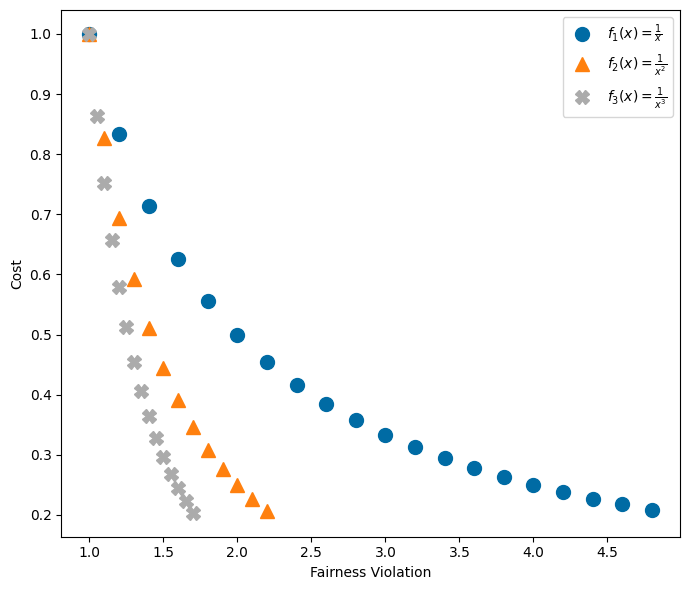

In [4]:
fig, ax = plt.subplots(figsize=(7,6))

x = np.arange(1.0, 5.0, 0.2)
y = 1/x
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f_1(x)=\frac{1}{x}$')

x = np.arange(1.0, 2.3, 0.1)
y = 1/(x**2)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, '^', label=r'$f_2(x)=\frac{1}{x^2}$')

x = np.arange(1.0, 1.75, 0.05)
y = 1/(x**3)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'X', label=r'$f_3(x)=\frac{1}{x^3}$')

ax.set_ylabel('Cost')
ax.set_xlabel('Fairness Violation')
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)

5.0
5.0
4.999999999999999


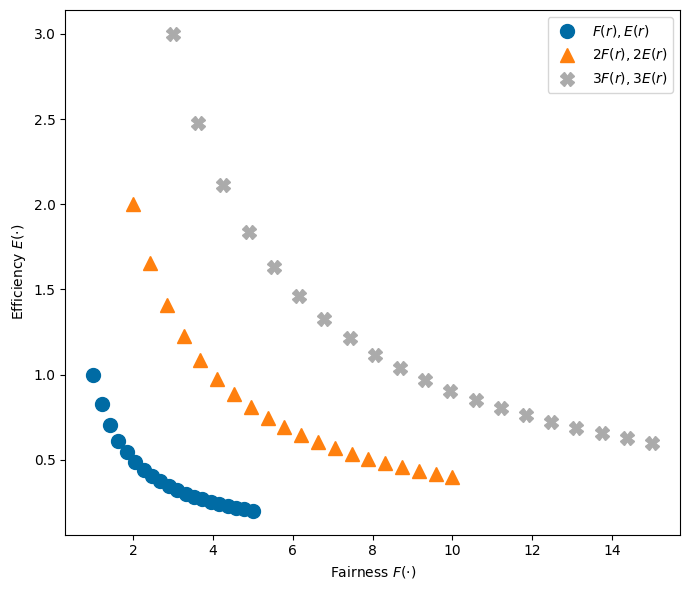

In [5]:
fig, ax = plt.subplots(figsize=(7,6))

x = np.linspace(1.0, 5.0, 20)
y = 1/x
print(np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$F(r), E(r)$')

x1 = x*2
y1 = y*2
print(np.max(y1)/np.min(y1))
ax.plot(x1, y1, '^', label=r'$2F(r), 2E(r)$')

x2 = x*3
y2 = y*3
print(np.max(y2)/np.min(y2))
ax.plot(x2, y2, 'X', label=r'$3F(r), 3E(r)$')

ax.set_ylabel(r'Efficiency $E(\cdot)$')
ax.set_xlabel(r'Fairness $F(\cdot)$')

ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)

[1.         0.82608696 0.7037037  0.61290323 0.54285714 0.48717949
 0.44186047 0.40425532 0.37254902 0.34545455 0.3220339  0.3015873
 0.28358209 0.26760563 0.25333333 0.24050633 0.22891566 0.2183908
 0.20879121 0.2       ] [1.         1.21052632 1.42105263 1.63157895 1.84210526 2.05263158
 2.26315789 2.47368421 2.68421053 2.89473684 3.10526316 3.31578947
 3.52631579 3.73684211 3.94736842 4.15789474 4.36842105 4.57894737
 4.78947368 5.        ] 5.0
[1.         0.82608696 0.7037037  0.61290323 0.54285714 0.48717949
 0.44186047 0.40425532 0.37254902 0.34545455 0.3220339  0.3015873
 0.28358209 0.26760563 0.25333333 0.24050633 0.22891566 0.2183908
 0.20879121 0.2       ] [ 2.          2.42105263  2.84210526  3.26315789  3.68421053  4.10526316
  4.52631579  4.94736842  5.36842105  5.78947368  6.21052632  6.63157895
  7.05263158  7.47368421  7.89473684  8.31578947  8.73684211  9.15789474
  9.57894737 10.        ] 5.0
[1.         0.82608696 0.7037037  0.61290323 0.54285714 0.48717949
 0.441860

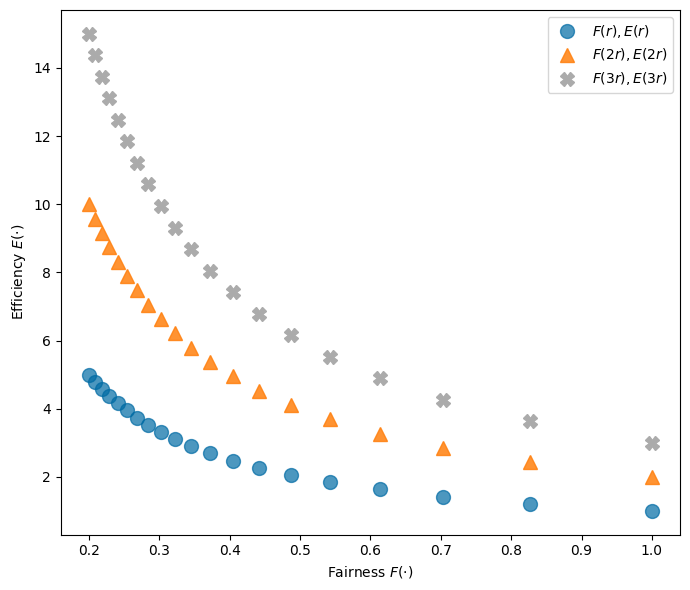

In [6]:
fig, ax = plt.subplots(figsize=(7,6))

r = np.linspace(1.0, 5.0, 20)
x = 1/r
y = r
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$F(r), E(r)$', alpha = 0.7)

r1 = 2*r
x1 = 1/r
y1 = r1
print(x1, y1, np.max(y1)/np.min(y1))
ax.plot(x1, y1, '^', label=r'$F(2r), E(2r)$', alpha = 0.85)

r2 = 3*r
x2 = 1/r
y2 = r2
print(x2, y2, np.max(y2)/np.min(y2))
ax.plot(x2, y2, 'X', label=r'$F(3r), E(3r)$', alpha = 1)

ax.set_ylabel(r'Efficiency $E(\cdot)$')
ax.set_xlabel(r'Fairness $F(\cdot)$')
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/hyp_curves_resources.pdf', bbox_inches='tight', dpi=300)

[1.         0.68241966 0.4951989  0.37565036 0.29469388 0.23734385
 0.19524067 0.16342236 0.13879277 0.11933884 0.10370583 0.0909549
 0.0804188  0.07161278 0.06417778 0.05784329 0.05240238 0.04769454
 0.04359377 0.04      ] [1.         1.21052632 1.42105263 1.63157895 1.84210526 2.05263158
 2.26315789 2.47368421 2.68421053 2.89473684 3.10526316 3.31578947
 3.52631579 3.73684211 3.94736842 4.15789474 4.36842105 4.57894737
 4.78947368 5.        ] 5.0
[0.25       0.17060491 0.12379973 0.09391259 0.07367347 0.05933596
 0.04881017 0.04085559 0.03469819 0.02983471 0.02592646 0.02273873
 0.0201047  0.01790319 0.01604444 0.01446082 0.0131006  0.01192364
 0.01089844 0.01      ] [ 2.          2.42105263  2.84210526  3.26315789  3.68421053  4.10526316
  4.52631579  4.94736842  5.36842105  5.78947368  6.21052632  6.63157895
  7.05263158  7.47368421  7.89473684  8.31578947  8.73684211  9.15789474
  9.57894737 10.        ] 5.0
[0.11111111 0.07582441 0.0550221  0.04173893 0.03274376 0.02637154
 0.021

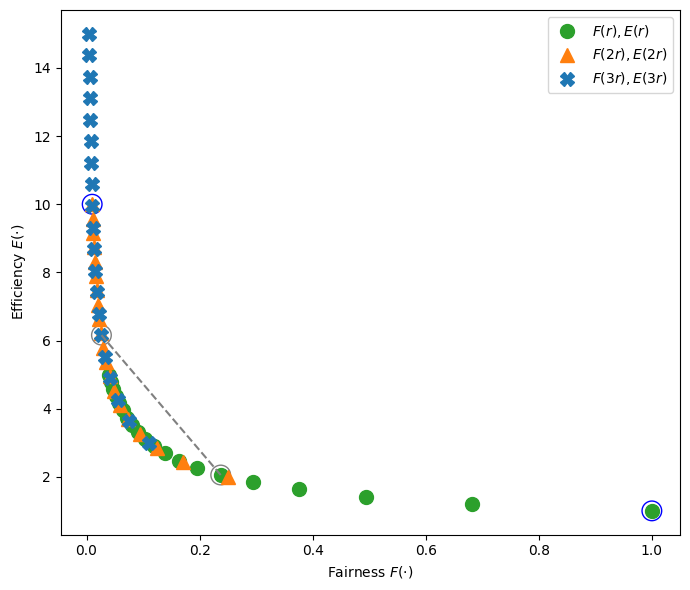

In [7]:
fig, ax = plt.subplots(figsize=(7,6))

r = np.linspace(1.0, 5.0, 20)
x = 1/(r**2)
y = r
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$F(r), E(r)$', color='tab:green')

r1 = 2*r
x1 = 1/(r1**2)
y1 = r1
print(x1, y1, np.max(y1)/np.min(y1))
ax.plot(x1, y1, '^', label=r'$F(2r), E(2r)$', color='tab:orange')

r2 = 3*r
x2 = 1/(r2**2)
y2 = r2
print(x2, y2, np.max(y2)/np.min(y2))
ax.plot(x2, y2, 'X', label=r'$F(3r), E(3r)$', color='tab:blue')

# add the circle for max welfare
circle_center1 = welfare(x, y, weight_x=1, weight_y=1/5)
print(f"welfare: {circle_center1}")
ax.scatter(circle_center1[0], circle_center1[1], s=200, 
           facecolors='none', edgecolors='b')
circle_center1 = welfare(x1, y1, weight_x=1, weight_y=0.5)
print(f"welfare: {circle_center1}")
ax.scatter(circle_center1[0], circle_center1[1], s=200, 
           facecolors='none', edgecolors='b')

circle_center1 = tuple((x[5], y[5]))
print(f"welfare: {circle_center1}")
ax.scatter(circle_center1[0], circle_center1[1], s=200, 
           facecolors='none', edgecolors='gray')

circle_center2 = tuple((x2[5], y2[5]))
print(f"welfare: {circle_center2}")
ax.scatter(circle_center2[0], circle_center2[1], s=200, 
           facecolors='none', edgecolors='gray')

# plot the dotted lines
x3 = np.array([circle_center1[0], circle_center2[0]])
y3 = np.array([circle_center1[1], circle_center2[1]])
ax.plot(x3, y3, '--', color='gray')

ax.set_ylabel(r'Efficiency $E(\cdot)$')
ax.set_xlabel(r'Fairness $F(\cdot)$')
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/hyp_curves_resources.pdf', bbox_inches='tight', dpi=300)

[1.         0.82608696 0.7037037  0.61290323 0.54285714 0.48717949
 0.44186047 0.40425532 0.37254902 0.34545455 0.3220339  0.3015873
 0.28358209 0.26760563 0.25333333 0.24050633 0.22891566 0.2183908
 0.20879121 0.2       ] 5.0
[0.5        0.41304348 0.35185185 0.30645161 0.27142857 0.24358974
 0.22093023 0.20212766 0.18627451 0.17272727 0.16101695 0.15079365
 0.14179104 0.13380282 0.12666667 0.12025316 0.11445783 0.1091954
 0.1043956  0.1       ] 5.0
[0.33333333 0.27536232 0.2345679  0.20430108 0.18095238 0.16239316
 0.14728682 0.13475177 0.12418301 0.11515152 0.10734463 0.1005291
 0.09452736 0.08920188 0.08444444 0.08016878 0.07630522 0.07279693
 0.06959707 0.06666667] 5.0


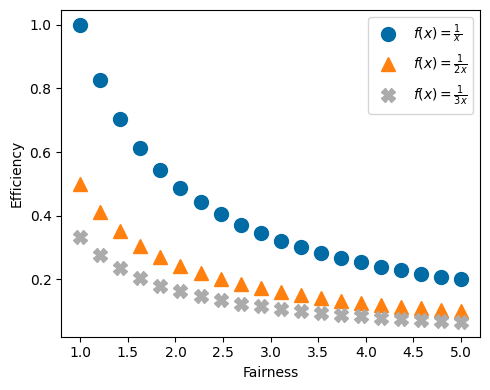

In [8]:
fig, ax = plt.subplots(figsize=(5,4))

x = np.linspace(1.0, 5, 20)
y = 1/x
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f(x)=\frac{1}{x}$')

# x = np.linspace(3.0, 6.0, 20)
y = 1/(2*x)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, '^', label=r'$f(x)=\frac{1}{2x}$')

# x = np.linspace(4.5, 6, 20)
y = 1/(3*x)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'X', label=r'$f(x)=\frac{1}{3x}$')

ax.set_ylabel('Efficiency')
ax.set_xlabel('Fairness')
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)

[4.         4.17391304 4.2962963  4.38709677 4.45714286 4.51282051
 4.55813953 4.59574468 4.62745098 4.65454545 4.6779661  4.6984127
 4.71641791 4.73239437 4.74666667 4.75949367 4.77108434 4.7816092
 4.79120879 4.8       ] 1.2
[4.5        4.58695652 4.64814815 4.69354839 4.72857143 4.75641026
 4.77906977 4.79787234 4.81372549 4.82727273 4.83898305 4.84920635
 4.85820896 4.86619718 4.87333333 4.87974684 4.88554217 4.8908046
 4.8956044  4.9       ] 1.088888888888889
[4.66666667 4.72463768 4.7654321  4.79569892 4.81904762 4.83760684
 4.85271318 4.86524823 4.87581699 4.88484848 4.89265537 4.8994709
 4.90547264 4.91079812 4.91555556 4.91983122 4.92369478 4.92720307
 4.93040293 4.93333333] 1.0571428571428572


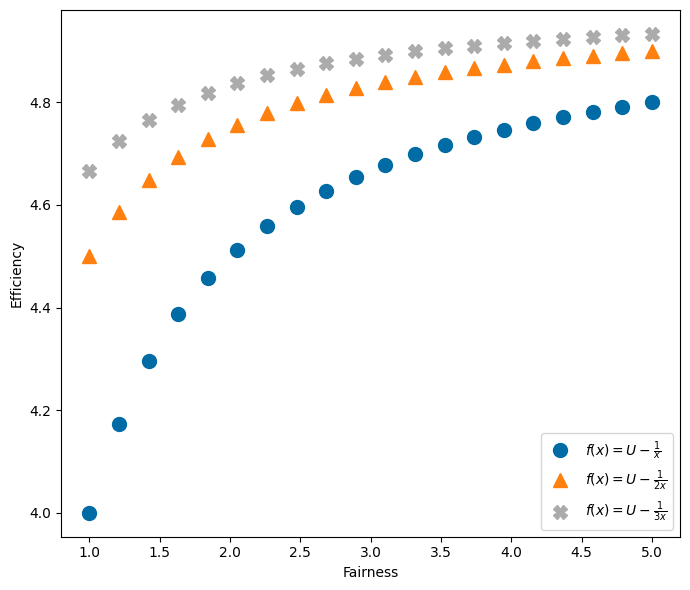

In [9]:
fig, ax = plt.subplots(figsize=(7,6))
U = 5

x = np.linspace(1.0, 5, 20)
y = U - (1/x)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f(x)=U-\frac{1}{x}$')

y = U - (1/(2*x))
print(y, np.max(y)/np.min(y))
ax.plot(x, y, '^', label=r'$f(x)=U-\frac{1}{2x}$')

y = U - (1/(3*x))
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'X', label=r'$f(x)=U-\frac{1}{3x}$')

ax.set_ylabel('Efficiency')
ax.set_xlabel('Fairness')
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)

### when HIGHER values for both are preferred

#### PoF example

[0.99498744 0.98728762 0.97952728 0.97170496 0.96381916 0.9558683
 0.94785075 0.93976481 0.93160868 0.92338052 0.91507837 0.90670021
 0.8982439  0.88970723 0.88108784 0.87238331 0.86359103 0.85470832
 0.84573232 0.83666003] [0.01       0.02526316 0.04052632 0.05578947 0.07105263 0.08631579
 0.10157895 0.11684211 0.13210526 0.14736842 0.16263158 0.17789474
 0.19315789 0.20842105 0.22368421 0.23894737 0.25421053 0.26947368
 0.28473684 0.3       ] 30.0
[0.98994949 0.9744094  0.95861743 0.9425609  0.92622607 0.90959794
 0.89266013 0.87539465 0.85778172 0.83979947 0.82142367 0.80262726
 0.78337999 0.76364776 0.74339194 0.72256852 0.70112691 0.67900857
 0.65614504 0.63245553] [0.01       0.02526316 0.04052632 0.05578947 0.07105263 0.08631579
 0.10157895 0.11684211 0.13210526 0.14736842 0.16263158 0.17789474
 0.19315789 0.20842105 0.22368421 0.23894737 0.25421053 0.26947368
 0.28473684 0.3       ] 30.0
[0.98488578 0.96135869 0.93724119 0.91248648 0.88704121 0.86084414
 0.83382442 0.8058993  0

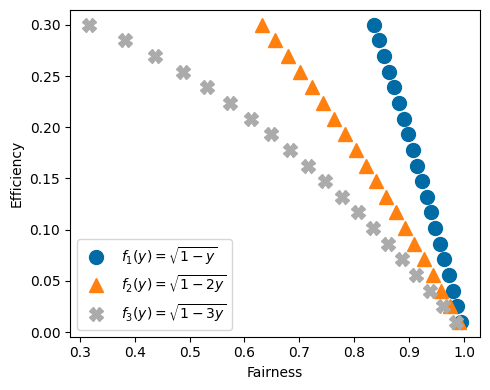

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
U = 1
# U = 1

# x = np.linspace(1, 5, 20)
y = np.linspace(0.01, 0.3, 20)
x = np.sqrt(U-y)
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f_1(y)=\sqrt{1-y}$')

x = np.sqrt(U-(2*y))
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, '^', label=r'$f_2(y)=\sqrt{1-2y}$')

x = np.sqrt(U-(3*y))
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'X', label=r'$f_3(y)=\sqrt{1-3y}$')

ax.set_ylabel('Efficiency')
ax.set_xlabel('Fairness')
# ax.set_ylim(bottom=0.)
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)

welfare: 1.2499085073924388, x: 0.4904348231819124, y:0.7594736842105263
welfare: (np.float64(0.4904348231819124), np.float64(0.7594736842105263))
welfare: 1.4997720670907815, x: 1.0213510144592024, y:0.47842105263157897
welfare: (np.float64(1.0213510144592024), np.float64(0.47842105263157897))
welfare: 1.4997720670907815, x: 1.0213510144592024, y:0.47842105263157897
welfare: (np.float64(1.0213510144592024), np.float64(0.47842105263157897))
welfare: 1.749988870247137, x: 1.5057783439313475, y:0.2442105263157895
welfare: (np.float64(1.5057783439313475), np.float64(0.2442105263157895))
welfare: 1.749988870247137, x: 1.5057783439313475, y:0.2442105263157895
welfare: (np.float64(1.5057783439313475), np.float64(0.2442105263157895))


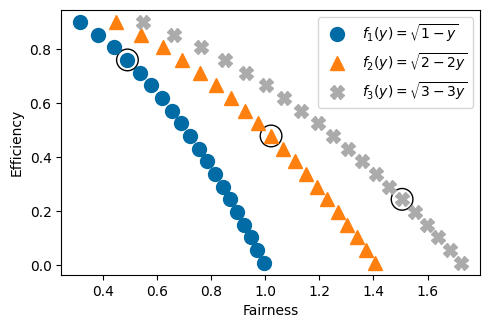

In [11]:
fig, ax = plt.subplots(figsize=(5,4))
y = np.linspace(0.01, 0.9, 20)
r=0.04

U = 1
x = np.sqrt(U-y)
# print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f_1(y)=\sqrt{1-y}$')
# add the circle for max welfare
circle_center = welfare(x, y)
print(f"welfare: {circle_center}")
circle = Circle(circle_center, r, fill = False)
ax.add_patch(circle)

U = 2
x = np.sqrt(U-(2*y))
# print(x, y, np.max(y)/np.min(y))
print(f"welfare: {welfare(x, y)}")
ax.plot(x, y, '^', label=r'$f_2(y)=\sqrt{2-2y}$')
# add the circle for max welfare
circle_center = welfare(x, y)
print(f"welfare: {circle_center}")
circle = Circle(circle_center, r, fill = False)
ax.add_patch(circle)

U = 3
x = np.sqrt(U-(3*y))
# print(x, y, np.max(y)/np.min(y))
print(f"welfare: {welfare(x, y)}")
ax.plot(x, y, 'X', label=r'$f_3(y)=\sqrt{3-3y}$')
# add the circle for max welfare
circle_center = welfare(x, y)
print(f"welfare: {circle_center}")
circle = Circle(circle_center, r, fill = False)
ax.add_patch(circle)

ax.set_ylabel('Efficiency')
ax.set_xlabel('Fairness')
ax.set_aspect('equal')
# ax.set_ylim(bottom=0.)
# ax.grid()
ax.legend()

plt.tight_layout()
plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)

#### resource example

[0.99498744 0.97116317 0.94673956 0.92166897 0.89589708 0.86936153
 0.84199012 0.81369851 0.78438712 0.75393703 0.72220423 0.6890115
 0.65413663 0.61729461 0.57810944 0.53606755 0.49043482 0.44009568
 0.38319982 0.31622777] [0.01       0.05684211 0.10368421 0.15052632 0.19736842 0.24421053
 0.29105263 0.33789474 0.38473684 0.43157895 0.47842105 0.52526316
 0.57210526 0.61894737 0.66578947 0.71263158 0.75947368 0.80631579
 0.85315789 0.9       ] 90.0
[1.98997487 1.94232633 1.89347911 1.84333793 1.79179416 1.73872306
 1.68398025 1.62739702 1.56877424 1.50787407 1.44440846 1.37802299
 1.30827327 1.23458921 1.15621888 1.07213511 0.98086965 0.88019137
 0.76639965 0.63245553] [0.02       0.11368421 0.20736842 0.30105263 0.39473684 0.48842105
 0.58210526 0.67578947 0.76947368 0.86315789 0.95684211 1.05052632
 1.14421053 1.23789474 1.33157895 1.42526316 1.51894737 1.61263158
 1.70631579 1.8       ] 90.0
welfare: 2.4998170147848775, x: 0.9808696463638248, y:1.5189473684210526
welfare: (np.float

<>:47: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\c'
/var/folders/d9/770yh1d13_jgblbmf5m8q2yh0000gn/T/ipykernel_48576/3240123515.py:47: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Fairness $F(\cdot)$')


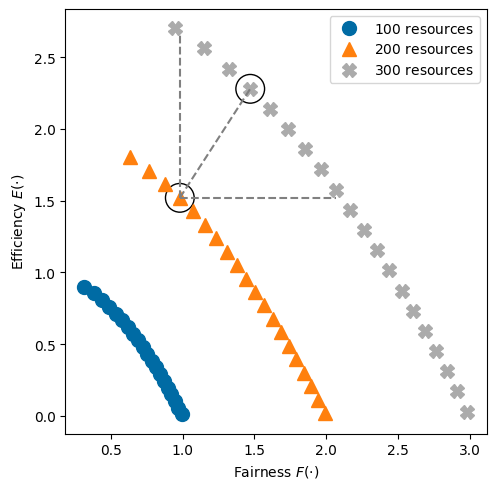

In [12]:
fig, ax = plt.subplots(figsize=(6,5))
U = 1
r=0.1
# U = 1

# x = np.linspace(1, 5, 20)
y = np.linspace(0.01, 0.9, 20)
x = np.sqrt(U-y)
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$100$ resources')

x1 = x * 2
y1 = y * 2
print(x1, y1, np.max(y)/np.min(y))
ax.plot(x1, y1, '^', label=r'$200$ resources')
# add the circle for max welfare
circle_center1 = welfare(x1, y1)
print(f"welfare: {circle_center1}")
circle = Circle(circle_center1, r, fill = False)
ax.add_patch(circle)

x2 = x * 3
y2 = y * 3
print(x2, y2, np.max(y)/np.min(y))
ax.plot(x2, y2, 'X', label=r'$300$ resources')
# add the circle for max welfare
circle_center2 = welfare(x2, y2)
print(f"welfare: {circle_center2}")
circle = Circle(circle_center2, r, fill = False)
ax.add_patch(circle)

# plot the dotted lines
x3 = np.array([circle_center1[0], circle_center2[0]])
y3 = np.array([circle_center1[1], circle_center2[1]])
ax.plot(x3, y3, '--', color='gray')

x3 = np.array([circle_center1[0], circle_center2[0]+0.6])
y3 = np.array([circle_center1[1], circle_center1[1]])
ax.plot(x3, y3, '--', color='gray')

x3 = np.array([circle_center1[0], circle_center1[0]])
y3 = np.array([circle_center1[1], circle_center1[1]+1.15])
ax.plot(x3, y3, '--', color='gray')


ax.set_ylabel(r'Efficiency $E(\cdot)$')
ax.set_xlabel('Fairness $F(\cdot)$')
# ax.set_ylim(bottom=0.)
# ax.grid()
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.savefig('./figs/pof_curves_resources.pdf', bbox_inches='tight', dpi=300)

[0.99498744 0.88663547 0.76304973 0.61511572 0.41771976        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan] [ 0.01        0.21387755  0.4177551   0.62163265  0.8255102   1.02938776
  1.23326531  1.43714286  1.64102041  1.84489796  2.04877551  2.25265306
  2.45653061  2.66040816  2.86428571  3.06816327  3.27204082  3.47591837
  3.67979592  3.88367347  4.08755102  4.29142857  4.49530612  4.69918367
  4.90306122  5.10693878  5.31081633  5.51469388  5.71857143  5.92244898
  6.12632653  6.33020408  6.53408163  6.73795918  6.94183673  7.14571429
  

/var/folders/d9/770yh1d13_jgblbmf5m8q2yh0000gn/T/ipykernel_48576/3870650727.py:11: RuntimeWarning: invalid value encountered in sqrt
  x = np.sqrt(U-y)
/var/folders/d9/770yh1d13_jgblbmf5m8q2yh0000gn/T/ipykernel_48576/3870650727.py:15: RuntimeWarning: invalid value encountered in sqrt
  x = (np.sqrt(U-(y/2)))*2
/var/folders/d9/770yh1d13_jgblbmf5m8q2yh0000gn/T/ipykernel_48576/3870650727.py:19: RuntimeWarning: invalid value encountered in sqrt
  x = (np.sqrt(U-(y/3)))*3


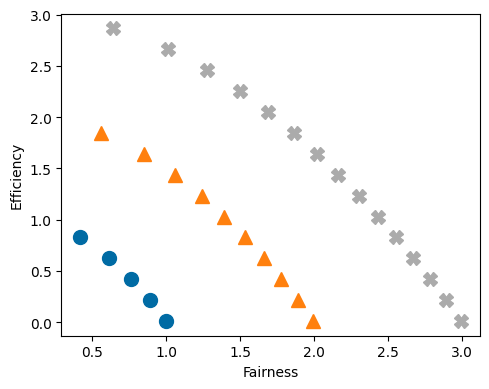

In [13]:
# the plot has the same PoF cause it's calculated 
# over the range of y and not necessarily the 
# support of the f(y), where the value is a 
# non-negative number
fig, ax = plt.subplots(figsize=(5,4))
U = 1
# U = 1

# x = np.linspace(1, 5, 20)
y = np.linspace(0.01, 10, 50)
x = np.sqrt(U-y)
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f_1(y)=\sqrt{1-y}$')

x = (np.sqrt(U-(y/2)))*2
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, '^', label=r'$f_2(y)=2f_1(2y)$')

x = (np.sqrt(U-(y/3)))*3
print(x, y, np.max(y)/np.min(y))
ax.plot(x, y, 'X', label=r'$f_2(y)=3f_1(2y)$')

ax.set_ylabel('Efficiency')
ax.set_xlabel('Fairness')
# ax.set_ylim(bottom=0.)
# ax.grid()
# ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves_resources.pdf', bbox_inches='tight', dpi=300)

### utility -- input vs output

In [14]:
def maximizing_efficiency(utils, ub):
    return np.mean(utils)

In [15]:
def minimizing_efficiency(utils, ub):
    return ub-np.mean(utils)

In [16]:
def absolute_fairness(utils, eff, ub=1):
    # ub = np.sqrt(2)
    # ub=22
    util_violation = (utils - eff)**2
    # print(f"eff:{eff}, utils: {utils}, violation: {util_violation}, ub: {ub}")
    return (ub-np.sqrt(np.sum(util_violation)))

In [17]:
def absolute_unfairness(utils, eff, ub):
    util_violation = (utils - eff)**2
    # print(f"eff:{eff}, utils: {utils}, violation: {util_violation}, ub: {ub}")
    return (np.sqrt(np.sum(util_violation)))

In [18]:
def relative_fairness(utils, eff, ub):
    numer = np.minimum(utils, eff)
    denom = np.maximum(utils, eff)
    util_violation = np.divide(numer, denom, out=np.ones_like(utils), where=(denom!=0))
    return (gmean(util_violation))

In [19]:
def relative_unfairness(utils, eff, ub):
    ub = 1
    numer = np.minimum(utils, eff)
    denom = np.maximum(utils, eff)
    util_violation = np.divide(numer, denom, out=np.ones_like(utils), where=(denom!=0))
    return (ub-gmean(util_violation))

In [20]:
def linear_util(alc):
    util_weights = np.arange(alc.shape[0], 0, -1)
    return util_weights*alc

In [21]:
def min_linear_util(alc):
    util_weights = np.arange(1, alc.shape[0]+1, 1)
    return 22-(util_weights*alc)

#### min inverse utils = $\frac{1}{x} + \frac{1}{2(R-x)}$

Fair solution:
$x= 2(R-x)$

Eff solution:
$\frac{d}{dx}(\frac{1}{x} + \frac{1}{2(R-x)}) = 0$

In [22]:
def min_inverse_util(alc):
    # util_weights = np.arange(alc.shape[0], 0, -1)
    # return np.divide(np.ones_like(alc), -1*util_weights*alc, out=np.zeros_like(alc), where=(alc!=0))+1
    util_weights = np.arange(1, alc.shape[0]+1, 1)
    return np.divide(np.ones_like(alc), util_weights*alc, out=np.ones_like(alc), where=(alc!=0))
    # return 1-(1/(util_weights[nz_idx]*alc[nz_idx]))
    # return R-np.mean(1/(util_weights[nz_idx]*alc[nz_idx]))

#### max inverse utils = $1-(\frac{1}{2x}+\frac{1}{R-x})$
Fair solution:
$2x= R-x$

Eff solution:
$\frac{d}{dx}(1-\frac{1}{2x}-\frac{1}{R-x}) = 0$

In [23]:
def max_inverse_util(alc):
    util_weights = np.arange(alc.shape[0], 0, -1)
    return 1-np.divide(np.ones_like(alc), util_weights*alc, out=np.ones_like(alc), where=(alc!=0))
    # return 1-(1/(util_weights[nz_idx]*alc[nz_idx]))
    # return R-np.mean(1/(util_weights[nz_idx]*alc[nz_idx]))

In [24]:
def r_ub(r, mul):
    return mul*r

In [25]:
def no_share(r):
    return 0

In [26]:
def twice_share(r):
    return 2*r

In [27]:
def complete_share(r):
    return r

In [28]:
def equal_share(r):
    return r/2

In [29]:
def one_less(r):
    return r-1

In [30]:
def linear_proportional_share(r):
    return r/3

In [31]:
def min_linear_proportional_share(r):
    return (2*r)/3

In [32]:
def inverse_proportional_share(r):
    return 3/(2*r)

In [33]:
def resource_cycle(R, start, np_util_fn, 
                   np_fair_fn, np_fair_ub,
                   eff_fn, eff_ub, 
                   pref_fair_share_fn=equal_share, pref_eff_share_fn=complete_share):
    x1, y1 = np.zeros(R-start), np.zeros(R-start)
    x2, y2 = np.zeros(R-start), np.zeros(R-start)

    for r in range(start, R):
        idx = r-start

        alc_fair = np.zeros(2)
        # give less to 0th position
        # alc_fair[0] = np.ceil(r/3) for linear, np.ceil(3/(2*r)) for inverse
        alc_fair[0] = pref_fair_share_fn(r)
        alc_fair[1] = r - alc_fair[0]
        assert(np.sum(alc_fair)==r and np.all(alc_fair>=0))
        utils_fair = np.apply_along_axis(np_util_fn, 0, alc_fair)
        print(f"fair alc: {alc_fair}, fair utils: {utils_fair}")
        y1[idx] = eff_fn(utils_fair, eff_ub)
        x1[idx] = np.apply_along_axis(np_fair_fn, 0, utils_fair, y1[idx], np_fair_ub)

        alc_eff = np.zeros(2)
        # give more to 0th position
        alc_eff[0] = pref_eff_share_fn(r)
        alc_eff[1] = r - alc_eff[0]
        assert(np.sum(alc_eff)==r and np.all(alc_eff>=0))
        utils_eff = np.apply_along_axis(np_util_fn, 0, alc_eff)
        print(f"eff alc: {alc_eff}, eff utils: {utils_eff}")
        y2[idx] = eff_fn(utils_eff, eff_ub)
        x2[idx] = np.apply_along_axis(np_fair_fn, 0, utils_eff, y2[idx], np_fair_ub)
    return x1, y1, x2, y2

In [34]:
def plot_util_graphs(x1, y1, x2, y2, xlabel, ylabel, savepath=None):
    fig, ax = plt.subplots(figsize=(5,4))
    alphas = np.linspace(0.5, 1, x1.shape[0])
    # alphas = np.ones_like(x1)
    ax.scatter(x2, y2, label='Efficient allocation', marker='o', alpha=alphas)
    ax.scatter(x1, y1, label='Fair allocation', marker='^', alpha=alphas)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    leg = ax.legend()
    for lh in leg.legend_handles:
        lh.set_alpha([1])

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=300)

#### linear util plots

fair alc: [0.66666667 1.33333333], fair utils: [1.33333333 1.33333333]
eff alc: [2. 0.], eff utils: [4. 0.]
fair alc: [1. 2.], fair utils: [2. 2.]
eff alc: [3. 0.], eff utils: [6. 0.]
fair alc: [1.33333333 2.66666667], fair utils: [2.66666667 2.66666667]
eff alc: [4. 0.], eff utils: [8. 0.]
fair alc: [1.66666667 3.33333333], fair utils: [3.33333333 3.33333333]
eff alc: [5. 0.], eff utils: [10.  0.]
fair alc: [2. 4.], fair utils: [4. 4.]
eff alc: [6. 0.], eff utils: [12.  0.]
fair alc: [2.33333333 4.66666667], fair utils: [4.66666667 4.66666667]
eff alc: [7. 0.], eff utils: [14.  0.]
fair alc: [2.66666667 5.33333333], fair utils: [5.33333333 5.33333333]
eff alc: [8. 0.], eff utils: [16.  0.]
fair alc: [3. 6.], fair utils: [6. 6.]
eff alc: [9. 0.], eff utils: [18.  0.]
fair alc: [3.33333333 6.66666667], fair utils: [6.66666667 6.66666667]
eff alc: [10.  0.], eff utils: [20.  0.]
<ff>, <fe>, <ef>, <ee>
[[15.55634919  1.33333333 12.72792206  2.        ]
 [15.55634919  2.         11.3137085

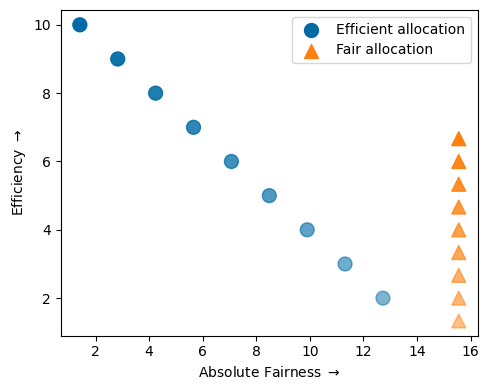

In [35]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=linear_util, 
                                np_fair_fn=absolute_fairness, np_fair_ub=11*np.sqrt(2),
                                eff_fn=maximizing_efficiency, eff_ub=1, 
                                pref_fair_share_fn=linear_proportional_share)
print("<ff>, <fe>, <ef>, <ee>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Absolute Fairness $\rightarrow$', r'Efficiency $\rightarrow$', 
                 savepath='./figs/linearutil_eff_absfair.pdf')

fair alc: [0.66666667 1.33333333], fair utils: [1.33333333 1.33333333]
eff alc: [2. 0.], eff utils: [4. 0.]
fair alc: [1. 2.], fair utils: [2. 2.]
eff alc: [3. 0.], eff utils: [6. 0.]
fair alc: [1.33333333 2.66666667], fair utils: [2.66666667 2.66666667]
eff alc: [4. 0.], eff utils: [8. 0.]
fair alc: [1.66666667 3.33333333], fair utils: [3.33333333 3.33333333]
eff alc: [5. 0.], eff utils: [10.  0.]
fair alc: [2. 4.], fair utils: [4. 4.]
eff alc: [6. 0.], eff utils: [12.  0.]
fair alc: [2.33333333 4.66666667], fair utils: [4.66666667 4.66666667]
eff alc: [7. 0.], eff utils: [14.  0.]
fair alc: [2.66666667 5.33333333], fair utils: [5.33333333 5.33333333]
eff alc: [8. 0.], eff utils: [16.  0.]
fair alc: [3. 6.], fair utils: [6. 6.]
eff alc: [9. 0.], eff utils: [18.  0.]
fair alc: [3.33333333 6.66666667], fair utils: [6.66666667 6.66666667]
eff alc: [10.  0.], eff utils: [20.  0.]
<ff>, <fe>, <ef>, <ee>
[[ 1.          1.33333333  0.          2.        ]
 [ 1.          2.          0.       

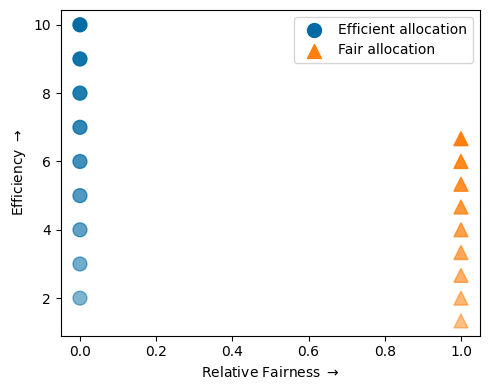

In [36]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=linear_util, 
                                np_fair_fn=relative_fairness, np_fair_ub=22,
                                eff_fn=maximizing_efficiency, eff_ub=1, 
                                pref_fair_share_fn=linear_proportional_share)
print("<ff>, <fe>, <ef>, <ee>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Relative Fairness $\rightarrow$', r'Efficiency $\rightarrow$', 
                 savepath='./figs/linearutil_eff_relfair.pdf')

fair alc: [1.33333333 0.66666667], fair utils: [20.66666667 20.66666667]
eff alc: [0. 2.], eff utils: [22. 18.]
fair alc: [2. 1.], fair utils: [20. 20.]
eff alc: [0. 3.], eff utils: [22. 16.]
fair alc: [2.66666667 1.33333333], fair utils: [19.33333333 19.33333333]
eff alc: [0. 4.], eff utils: [22. 14.]
fair alc: [3.33333333 1.66666667], fair utils: [18.66666667 18.66666667]
eff alc: [0. 5.], eff utils: [22. 12.]
fair alc: [4. 2.], fair utils: [18. 18.]
eff alc: [0. 6.], eff utils: [22. 10.]
fair alc: [4.66666667 2.33333333], fair utils: [17.33333333 17.33333333]
eff alc: [0. 7.], eff utils: [22.  8.]
fair alc: [5.33333333 2.66666667], fair utils: [16.66666667 16.66666667]
eff alc: [0. 8.], eff utils: [22.  6.]
fair alc: [6. 3.], fair utils: [16. 16.]
eff alc: [0. 9.], eff utils: [22.  4.]
fair alc: [6.66666667 3.33333333], fair utils: [15.33333333 15.33333333]
eff alc: [ 0. 10.], eff utils: [22.  2.]
<ff>, <fe>, <ef>, <ee>
[[15.55634919 20.66666667 12.72792206 20.        ]
 [15.5563491

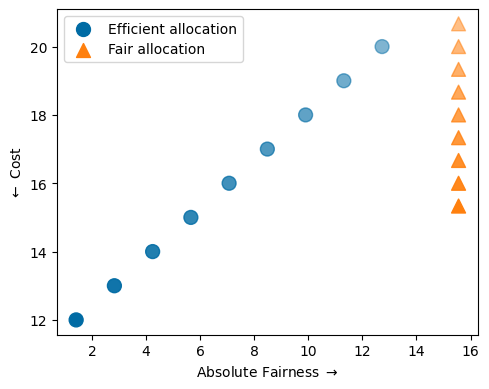

In [37]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=min_linear_util, 
                                np_fair_fn=absolute_fairness, np_fair_ub=11*np.sqrt(2),
                                eff_fn=maximizing_efficiency, eff_ub=22, 
                                pref_fair_share_fn=min_linear_proportional_share, 
                                pref_eff_share_fn=no_share)
print("<ff>, <fe>, <ef>, <ee>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Absolute Fairness $\rightarrow$', r'$\leftarrow$ Cost', 
                 savepath='./figs/linearutil_cost_absfair.pdf')

fair alc: [1.33333333 0.66666667], fair utils: [20.66666667 20.66666667]
eff alc: [0. 2.], eff utils: [22. 18.]
fair alc: [2. 1.], fair utils: [20. 20.]
eff alc: [0. 3.], eff utils: [22. 16.]
fair alc: [2.66666667 1.33333333], fair utils: [19.33333333 19.33333333]
eff alc: [0. 4.], eff utils: [22. 14.]
fair alc: [3.33333333 1.66666667], fair utils: [18.66666667 18.66666667]
eff alc: [0. 5.], eff utils: [22. 12.]
fair alc: [4. 2.], fair utils: [18. 18.]
eff alc: [0. 6.], eff utils: [22. 10.]
fair alc: [4.66666667 2.33333333], fair utils: [17.33333333 17.33333333]
eff alc: [0. 7.], eff utils: [22.  8.]
fair alc: [5.33333333 2.66666667], fair utils: [16.66666667 16.66666667]
eff alc: [0. 8.], eff utils: [22.  6.]
fair alc: [6. 3.], fair utils: [16. 16.]
eff alc: [0. 9.], eff utils: [22.  4.]
fair alc: [6.66666667 3.33333333], fair utils: [15.33333333 15.33333333]
eff alc: [ 0. 10.], eff utils: [22.  2.]
<ff>, <fe>, <ef>, <ee>
[[ 1.         20.66666667  0.90453403 20.        ]
 [ 1.       

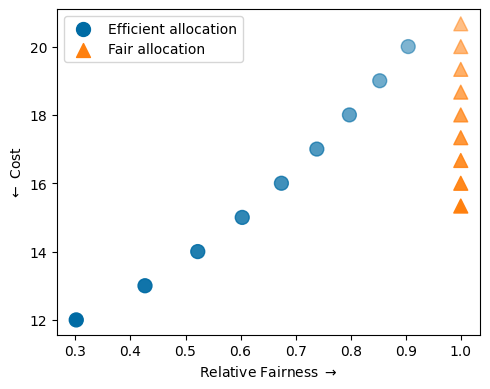

In [38]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=min_linear_util, 
                                np_fair_fn=relative_fairness, np_fair_ub=11*np.sqrt(2),
                                eff_fn=maximizing_efficiency, eff_ub=22, 
                                pref_fair_share_fn=min_linear_proportional_share, 
                                pref_eff_share_fn=no_share)
print("<ff>, <fe>, <ef>, <ee>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Relative Fairness $\rightarrow$', r'$\leftarrow$ Cost', 
                 savepath='./figs/linearutil_cost_relfair.pdf')

#### inverse util plots

####
pref_group = $\frac{1}{(1+\sqrt{2})}r$ = $(\sqrt{2}-1)r$

In [39]:
def max_inverse_util_share(r):
    # return (np.sqrt(2)-1)*r
    return (1/(1+np.sqrt(2)))*r

####
pref_group = $\frac{\sqrt{2}}{(1+\sqrt{2})}r$ = $(2-\sqrt{2})r$

In [40]:
def min_inverse_util_share(r):
    # return (2-np.sqrt(2))*r
    
    return (np.sqrt(2)/(1+np.sqrt(2)))*r

fair alc: [0.66666667 1.33333333], fair utils: [0.25 0.25]
eff alc: [0.82842712 1.17157288], eff utils: [0.39644661 0.14644661]
fair alc: [1. 2.], fair utils: [0.5 0.5]
eff alc: [1.24264069 1.75735931], eff utils: [0.59763107 0.43096441]
fair alc: [1.33333333 2.66666667], fair utils: [0.625 0.625]
eff alc: [1.65685425 2.34314575], eff utils: [0.6982233 0.5732233]
fair alc: [1.66666667 3.33333333], fair utils: [0.7 0.7]
eff alc: [2.07106781 2.92893219], eff utils: [0.75857864 0.65857864]
fair alc: [2. 4.], fair utils: [0.75 0.75]
eff alc: [2.48528137 3.51471863], eff utils: [0.79881554 0.7154822 ]
fair alc: [2.33333333 4.66666667], fair utils: [0.78571429 0.78571429]
eff alc: [2.89949494 4.10050506], eff utils: [0.82755617 0.7561276 ]
fair alc: [2.66666667 5.33333333], fair utils: [0.8125 0.8125]
eff alc: [3.3137085 4.6862915], eff utils: [0.84911165 0.78661165]
fair alc: [3. 6.], fair utils: [0.83333333 0.83333333]
eff alc: [3.72792206 5.27207794], eff utils: [0.86587702 0.81032147]
fa

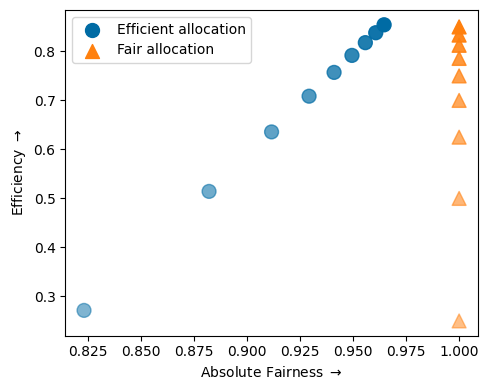

In [41]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=max_inverse_util, 
                                np_fair_fn=absolute_fairness, np_fair_ub=1, 
                                eff_fn=maximizing_efficiency, eff_ub=1, 
                                pref_fair_share_fn=linear_proportional_share, 
                                pref_eff_share_fn=max_inverse_util_share)
print("<ff>, <fe>, <ef>, <ee>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Absolute Fairness $\rightarrow$', r'Efficiency $\rightarrow$', 
                savepath='./figs/inverseutil_absfair_eff.pdf')

fair alc: [0.66666667 1.33333333], fair utils: [0.25 0.25]
eff alc: [0.82842712 1.17157288], eff utils: [0.39644661 0.14644661]
fair alc: [1. 2.], fair utils: [0.5 0.5]
eff alc: [1.24264069 1.75735931], eff utils: [0.59763107 0.43096441]
fair alc: [1.33333333 2.66666667], fair utils: [0.625 0.625]
eff alc: [1.65685425 2.34314575], eff utils: [0.6982233 0.5732233]
fair alc: [1.66666667 3.33333333], fair utils: [0.7 0.7]
eff alc: [2.07106781 2.92893219], eff utils: [0.75857864 0.65857864]
fair alc: [2. 4.], fair utils: [0.75 0.75]
eff alc: [2.48528137 3.51471863], eff utils: [0.79881554 0.7154822 ]
fair alc: [2.33333333 4.66666667], fair utils: [0.78571429 0.78571429]
eff alc: [2.89949494 4.10050506], eff utils: [0.82755617 0.7561276 ]
fair alc: [2.66666667 5.33333333], fair utils: [0.8125 0.8125]
eff alc: [3.3137085 4.6862915], eff utils: [0.84911165 0.78661165]
fair alc: [3. 6.], fair utils: [0.83333333 0.83333333]
eff alc: [3.72792206 5.27207794], eff utils: [0.86587702 0.81032147]
fa

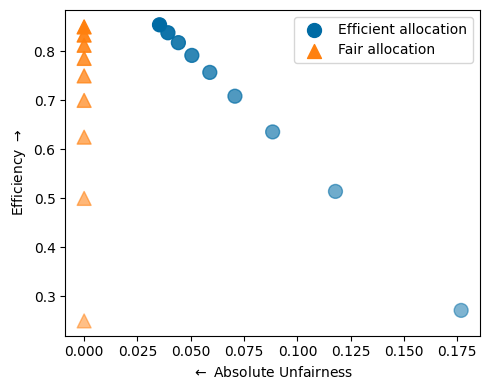

In [42]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=max_inverse_util, 
                                np_fair_fn=absolute_unfairness, np_fair_ub=1, 
                                eff_fn=maximizing_efficiency, eff_ub=1,
                                pref_fair_share_fn=linear_proportional_share, 
                                pref_eff_share_fn=max_inverse_util_share)
print("<ff>, <fe>, <ef>, <ee>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'$\leftarrow$ Absolute Unfairness', r'Efficiency $\rightarrow$')

fair alc: [0.66666667 1.33333333], fair utils: [0.25 0.25]
eff alc: [0.82842712 1.17157288], eff utils: [0.39644661 0.14644661]
fair alc: [1. 2.], fair utils: [0.5 0.5]
eff alc: [1.24264069 1.75735931], eff utils: [0.59763107 0.43096441]
fair alc: [1.33333333 2.66666667], fair utils: [0.625 0.625]
eff alc: [1.65685425 2.34314575], eff utils: [0.6982233 0.5732233]
fair alc: [1.66666667 3.33333333], fair utils: [0.7 0.7]
eff alc: [2.07106781 2.92893219], eff utils: [0.75857864 0.65857864]
fair alc: [2. 4.], fair utils: [0.75 0.75]
eff alc: [2.48528137 3.51471863], eff utils: [0.79881554 0.7154822 ]
fair alc: [2.33333333 4.66666667], fair utils: [0.78571429 0.78571429]
eff alc: [2.89949494 4.10050506], eff utils: [0.82755617 0.7561276 ]
fair alc: [2.66666667 5.33333333], fair utils: [0.8125 0.8125]
eff alc: [3.3137085 4.6862915], eff utils: [0.84911165 0.78661165]
fair alc: [3. 6.], fair utils: [0.83333333 0.83333333]
eff alc: [3.72792206 5.27207794], eff utils: [0.86587702 0.81032147]
fa

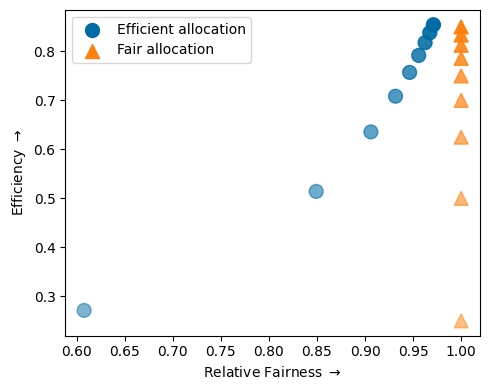

In [43]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=max_inverse_util, 
                                np_fair_fn=relative_fairness, np_fair_ub=1, 
                                eff_fn=maximizing_efficiency, eff_ub=1,
                                pref_fair_share_fn=linear_proportional_share, 
                                pref_eff_share_fn=max_inverse_util_share)
print("<ff>, <fe>, <ef>, <ee>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Relative Fairness $\rightarrow$', r'Efficiency $\rightarrow$', 
                 savepath='./figs/inverseutil_relfair_eff.pdf')

fair alc: [1.33333333 0.66666667], fair utils: [0.75 0.75]
eff alc: [1.17157288 0.82842712], eff utils: [0.85355339 0.60355339]
fair alc: [2. 1.], fair utils: [0.5 0.5]
eff alc: [1.75735931 1.24264069], eff utils: [0.56903559 0.40236893]
fair alc: [2.66666667 1.33333333], fair utils: [0.375 0.375]
eff alc: [2.34314575 1.65685425], eff utils: [0.4267767 0.3017767]
fair alc: [3.33333333 1.66666667], fair utils: [0.3 0.3]
eff alc: [2.92893219 2.07106781], eff utils: [0.34142136 0.24142136]
fair alc: [4. 2.], fair utils: [0.25 0.25]
eff alc: [3.51471863 2.48528137], eff utils: [0.2845178  0.20118446]
fair alc: [4.66666667 2.33333333], fair utils: [0.21428571 0.21428571]
eff alc: [4.10050506 2.89949494], eff utils: [0.2438724  0.17244383]
fair alc: [5.33333333 2.66666667], fair utils: [0.1875 0.1875]
eff alc: [4.6862915 3.3137085], eff utils: [0.21338835 0.15088835]
fair alc: [6. 3.], fair utils: [0.16666667 0.16666667]
eff alc: [5.27207794 3.72792206], eff utils: [0.18967853 0.13412298]
fa

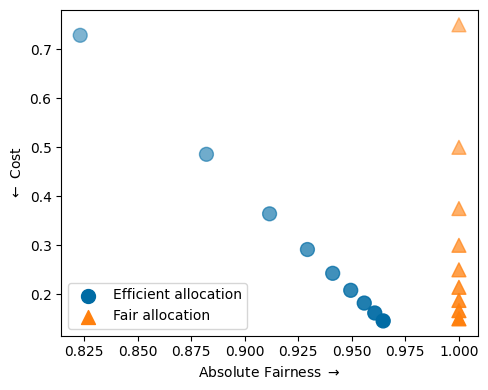

In [44]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=min_inverse_util, 
                                np_fair_fn=absolute_fairness, np_fair_ub=1,  
                                eff_fn=maximizing_efficiency, eff_ub=1,
                                pref_fair_share_fn=min_linear_proportional_share, 
                                pref_eff_share_fn=min_inverse_util_share)
print("<ff>, <fc>, <ef>, <ec>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Absolute Fairness $\rightarrow$', r'$\leftarrow$ Cost', 
                savepath='./figs/inverseutil_absfair_cost.pdf')

fair alc: [1.33333333 0.66666667], fair utils: [0.75 0.75]
eff alc: [1.17157288 0.82842712], eff utils: [0.85355339 0.60355339]
fair alc: [2. 1.], fair utils: [0.5 0.5]
eff alc: [1.75735931 1.24264069], eff utils: [0.56903559 0.40236893]
fair alc: [2.66666667 1.33333333], fair utils: [0.375 0.375]
eff alc: [2.34314575 1.65685425], eff utils: [0.4267767 0.3017767]
fair alc: [3.33333333 1.66666667], fair utils: [0.3 0.3]
eff alc: [2.92893219 2.07106781], eff utils: [0.34142136 0.24142136]
fair alc: [4. 2.], fair utils: [0.25 0.25]
eff alc: [3.51471863 2.48528137], eff utils: [0.2845178  0.20118446]
fair alc: [4.66666667 2.33333333], fair utils: [0.21428571 0.21428571]
eff alc: [4.10050506 2.89949494], eff utils: [0.2438724  0.17244383]
fair alc: [5.33333333 2.66666667], fair utils: [0.1875 0.1875]
eff alc: [4.6862915 3.3137085], eff utils: [0.21338835 0.15088835]
fair alc: [6. 3.], fair utils: [0.16666667 0.16666667]
eff alc: [5.27207794 3.72792206], eff utils: [0.18967853 0.13412298]
fa

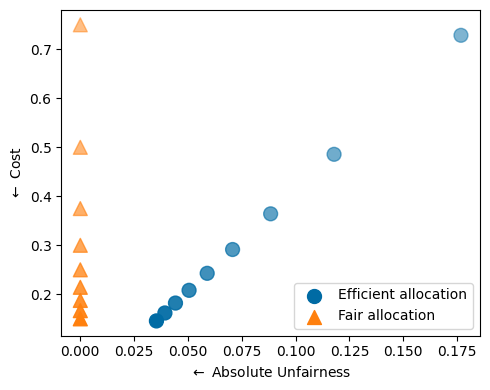

In [45]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=min_inverse_util, 
                                np_fair_fn=absolute_unfairness, np_fair_ub=1,  
                                eff_fn=maximizing_efficiency, eff_ub=1,
                                pref_fair_share_fn=min_linear_proportional_share, 
                                pref_eff_share_fn=min_inverse_util_share)
print("<ff>, <fc>, <ef>, <ec>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'$\leftarrow$ Absolute Unfairness', r'$\leftarrow$ Cost')

fair alc: [1.33333333 0.66666667], fair utils: [0.75 0.75]
eff alc: [1.17157288 0.82842712], eff utils: [0.85355339 0.60355339]
fair alc: [2. 1.], fair utils: [0.5 0.5]
eff alc: [1.75735931 1.24264069], eff utils: [0.56903559 0.40236893]
fair alc: [2.66666667 1.33333333], fair utils: [0.375 0.375]
eff alc: [2.34314575 1.65685425], eff utils: [0.4267767 0.3017767]
fair alc: [3.33333333 1.66666667], fair utils: [0.3 0.3]
eff alc: [2.92893219 2.07106781], eff utils: [0.34142136 0.24142136]
fair alc: [4. 2.], fair utils: [0.25 0.25]
eff alc: [3.51471863 2.48528137], eff utils: [0.2845178  0.20118446]
fair alc: [4.66666667 2.33333333], fair utils: [0.21428571 0.21428571]
eff alc: [4.10050506 2.89949494], eff utils: [0.2438724  0.17244383]
fair alc: [5.33333333 2.66666667], fair utils: [0.1875 0.1875]
eff alc: [4.6862915 3.3137085], eff utils: [0.21338835 0.15088835]
fair alc: [6. 3.], fair utils: [0.16666667 0.16666667]
eff alc: [5.27207794 3.72792206], eff utils: [0.18967853 0.13412298]
fa

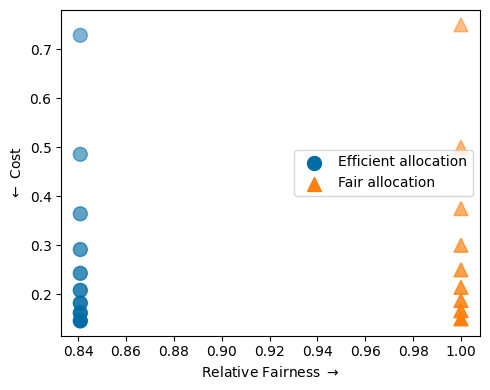

In [46]:
x1, y1, x2, y2 = resource_cycle(R=11, start=2, np_util_fn=min_inverse_util, 
                                np_fair_fn=relative_fairness, np_fair_ub=1,  
                                eff_fn=maximizing_efficiency, eff_ub=1,
                                pref_fair_share_fn=min_linear_proportional_share, 
                                pref_eff_share_fn=min_inverse_util_share)
print("<ff>, <fc>, <ef>, <ec>")
print(f"{np.stack((x1, y1, x2, y2), axis=1)}")
plot_util_graphs(x1, y1, x2, y2, r'Relative Fairness $\rightarrow$', r'$\leftarrow$ Cost', 
                savepath='./figs/inverseutil_relfair_cost.pdf')

#### different range of y

[0.99       0.97980609 0.96606648 0.94878116 0.92795014 0.90357341
 0.87565097 0.84418283 0.80916898 0.77060942 0.72850416 0.68285319
 0.63365651 0.58091413 0.52462604 0.46479224 0.40141274 0.33448753
 0.26401662 0.19      ] 5.210526315789475
[3.96       3.91922438 3.86426593 3.79512465 3.71180055 3.61429363
 3.50260388 3.3767313  3.2366759  3.08243767 2.91401662 2.73141274
 2.53462604 2.32365651 2.09850416 1.85916898 1.60565097 1.33795014
 1.05606648 0.76      ] 5.210526315789475
[8.91       8.81825485 8.69459834 8.53903047 8.35155125 8.13216066
 7.88085873 7.59764543 7.28252078 6.93548476 6.5565374  6.14567867
 5.70290859 5.22822715 4.72163435 4.18313019 3.61271468 3.01038781
 2.37614958 1.71      ] 5.210526315789477


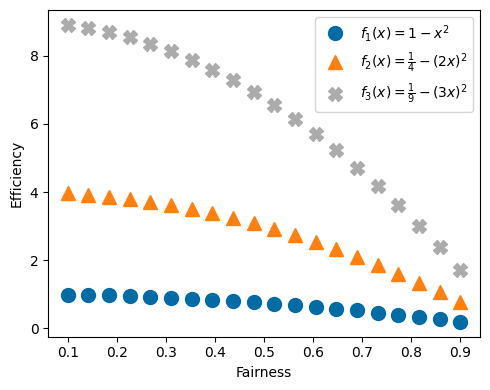

In [47]:
fig, ax = plt.subplots(figsize=(5,4))
# U = 49
U = 1

# x = np.linspace(1, 5, 20)
x = np.linspace(0.1, 0.9, 20)
y = U - np.power(x,2)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f_1(x)=1-x^2$')

y = U*4 - np.power(x*2,2)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, '^', label=r'$f_2(x)=\frac{1}{4}-(2x)^2$')

y = U*9 - np.power(x*3,2)
print(y, np.max(y)/np.min(y))
ax.plot(x, y, 'X', label=r'$f_3(x)=\frac{1}{9}-(3x)^2$')

ax.set_ylabel('Efficiency')
ax.set_xlabel('Fairness')
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)

2.0
2.0
2.0


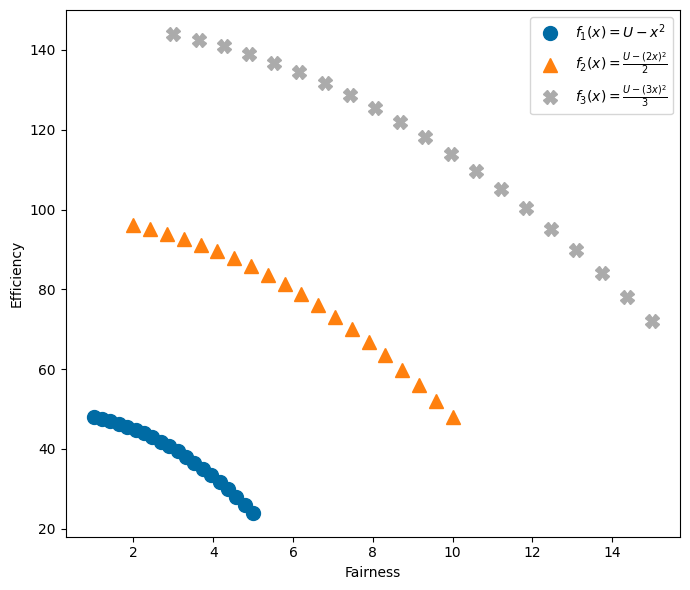

In [48]:
fig, ax = plt.subplots(figsize=(7,6))
U = 49

x = np.linspace(1.0, 5.0, 20)
y = U - np.power(x,2)
print(np.max(y)/np.min(y))
ax.plot(x, y, 'o', label=r'$f_1(x)=U-x^2$')

x1 = x*2
y1 = y*2
print(np.max(y1)/np.min(y1))
ax.plot(x1, y1, '^', label=r'$f_2(x)=\frac{U-(2x)^2}{2}$')

x2 = x*3
y2 = y*3
print(np.max(y2)/np.min(y2))
ax.plot(x2, y2, 'X', label=r'$f_3(x)=\frac{U-(3x)^2}{3}$')

ax.set_ylabel('Efficiency')
ax.set_xlabel('Fairness')
# ax.grid()
ax.legend()

plt.tight_layout()
# plt.savefig('./figs/pof_curves.pdf', bbox_inches='tight', dpi=300)